# 소성가공 예지보전 — PyTorch Colab 재현

**사용법:** Colab에 이 파일을 열고 **T4 GPU**를 선택한 뒤 위에서부터 실행하세요. 업로드 창에서 `press_data_normal.csv`, `outlier_data.csv`를 함께 선택합니다. 처음 환경 설치에는 시간이 걸립니다. 설정을 바꾼 경우 실행 환경 연결 셀부터 다시 실행하세요.

가이드에 적힌 **Python 3.9.7·NumPy 1.20.0**을 Colab 서버 안에 구성합니다. TensorFlow판은 **TensorFlow 2.7.0**, PyTorch판은 **PyTorch 2.7.0**을 사용합니다. `%%guide` 셀은 Colab 서버의 전용 Python 환경에서 실행하며, 셀 사이에 변수·모델이 유지되고 결과가 셀 아래에 표시됩니다.

PyTorch는 난수 생성·GPU 라이브러리도 다르므로 수치까지 동일함을 보장하지 않습니다. seed=42는 추가 설정이고 가이드 원문에는 없습니다.

출처: 중소벤처기업부·Korea AI Manufacturing Platform(KAMP), 『소성가공 예지보전 AI 데이터셋 분석실습 가이드북』, 2022.12.23.


## 1. Colab 환경 준비

PyTorch 2.7.0의 CUDA 12.6 배포본을 사용합니다. GPU 라이브러리는 TensorFlow 2.7 환경과 다릅니다. [공식 설치 버전 안내](https://pytorch.org/get-started/previous-versions/). 가이드에서 버전을 지정하지 않은 분석 패키지는 호환되는 버전으로 고정합니다.

In [48]:
# 모든 설치는 현재 Colab 서버의 /content 안에서 이루어집니다.
# Colab 기본 Python/패키지를 교체하지 않고 가이드용 Python 3.9.7을 실행합니다.
import os, sys, json, subprocess, urllib.request, tarfile, io
from pathlib import Path
try:
    from google.colab import files
except ImportError:
    raise RuntimeError("이 노트북은 Google Colab에서 열고 실행하세요.")
if sys.platform != "linux":
    raise RuntimeError("Colab의 호스팅 런타임을 선택하세요.")
gpu = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                     capture_output=True, text=True)
if gpu.returncode != 0:
    raise RuntimeError("런타임 → 런타임 유형 변경에서 T4 GPU를 선택하세요.")
print("Colab GPU:", gpu.stdout.strip())
print("Colab 기본 Python:", sys.version.split()[0], "→ 학습은 별도 Python 3.9.7에서 실행")

FRAMEWORK_NAME = "pytorch"
ENV_DIR = Path("/content/kamp_guide_" + FRAMEWORK_NAME)
MAMBA = Path("/content/kamp_tools/micromamba")
PYTHON = ENV_DIR / "bin/python"
if not MAMBA.is_file():
    MAMBA.parent.mkdir(parents=True, exist_ok=True)
    url = "https://github.com/mamba-org/micromamba-releases/releases/download/2.3.3-0/micromamba-linux-64"
    print("Colab에 환경 설치 도구 준비 중...")
    with urllib.request.urlopen(url, timeout=60) as response:
        MAMBA.write_bytes(response.read())
    MAMBA.chmod(0o755)

install_env = os.environ.copy()
install_env["MAMBA_ROOT_PREFIX"] = "/content/kamp_mamba"
install_env["PYTHONNOUSERSITE"] = "1"
# 가이드가 명시한 버전: Python 3.9.7, NumPy 1.20.0, TensorFlow 2.7.0.
# 버전이 적혀 있지 않은 분석 패키지는 해당 시기와 호환되는 버전으로 고정합니다.
PACKAGES = {'numpy': '1.20.0', 'pandas': '1.3.5', 'scikit-learn': '1.0.2', 'scipy': '1.7.3', 'matplotlib': '3.5.3', 'seaborn': '0.11.2', 'joblib': '1.1.0', 'ipykernel': '6.16.2', 'ipython': '8.18.1', 'jupyter-client': '7.4.9', 'matplotlib-inline': '0.1.6', 'traitlets': '5.9.0', 'setuptools': '65.5.0', 'torch': '2.7.0+cu126'}
spec = {"python":"3.9.7", "packages":PACKAGES, "gpu_libraries":'PyTorch CUDA 12.6 wheel dependencies'}
marker = ENV_DIR / ".kamp_setup.json"
ready = marker.is_file() and json.loads(marker.read_text()) == spec
if not ready:
    subprocess.check_call([str(MAMBA), "create" if not PYTHON.exists() else "install",
        "-y", "-p", str(ENV_DIR), "--override-channels", "-c", "conda-forge",
        "python=3.9.7", "pip=24.3.1", *[]], env=install_env)
    requirements = [name + "==" + version for name, version in PACKAGES.items()]
    subprocess.check_call([str(PYTHON), "-m", "pip", "install", "--only-binary=:all:",
                           *requirements, *['--extra-index-url', 'https://download.pytorch.org/whl/cu126']], env=install_env)
    subprocess.check_call([str(PYTHON), "-m", "pip", "check"], env=install_env)
    marker.write_text(json.dumps(spec), encoding="utf-8")
print("가이드용 Colab 환경 준비 완료. 세션 재시작 없이 다음 셀로 진행하세요.")


Colab GPU: Tesla T4
Colab 기본 Python: 3.13.15 → 학습은 별도 Python 3.9.7에서 실행
가이드용 Colab 환경 준비 완료. 세션 재시작 없이 다음 셀로 진행하세요.


## 2. 사용자 설정

In [49]:
# 실행 설정: Colab 서버 경로이며 개인 PC/Drive ID가 필요 없습니다.
DATA_SOURCE = "upload"              # upload 또는 existing
DATA_DIR = "/content/kamp_data"
OUTPUT_ROOT = "/content/kamp_pytorch_results"
RUN_ID = "run01"                    # 새 실험은 run02 등으로 변경
DOWNLOAD_RESULTS = False            # 마지막 셀에서 결과 ZIP 다운로드
REQUIRE_GPU = True

# 실험 기본 설정입니다.
CONFIG = dict(sequence=20, label_offset=100, train_rows=15000,
              valid_normal=880, valid_anomaly=300,
              epochs=800, batch_size=128, learning_rate=0.001,
              lr_factor=0.7, lr_patience=50,
              es_min_delta=0.00001, es_patience=120, seed=42)
# 처음 동작만 점검하려면 epochs=2, RUN_ID="smoke"로 바꿉니다.
# 설정을 바꾼 경우 환경 연결 셀부터 다시 실행하세요.


## 3. 가이드용 Python 실행 환경 연결

In [50]:
# %%guide 셀을 Colab 서버 안의 Python 3.9.7에서 실행합니다.
# 셀 사이의 변수·모델은 유지되고, 표·그래프·학습 로그는 해당 셀 바로 아래에 표시됩니다.
import atexit
from jupyter_client import KernelManager
from jupyter_client.kernelspec import KernelSpecManager
from IPython.core.magic import register_cell_magic
from IPython.display import display, clear_output

if "guide_manager" in globals():
    guide_client.stop_channels()
    guide_manager.shutdown_kernel(now=True)
kernel_dir = Path("/content/kamp_kernels/guide")
kernel_dir.mkdir(parents=True, exist_ok=True)
(kernel_dir/"kernel.json").write_text(json.dumps({
    "argv":[str(PYTHON), "-m", "ipykernel_launcher", "-f", "{connection_file}",
            "--IPKernelApp.kernel_class=ipykernel.ipkernel.IPythonKernel",
            "--IPKernelApp.extensions=[]"],
    "display_name":"KAMP guide Python 3.9.7", "language":"python"
}), encoding="utf-8")
kernel_env = os.environ.copy()
kernel_env.pop("PYTHONPATH", None)
kernel_env.pop("PYTHONHOME", None)
kernel_env["PYTHONNOUSERSITE"] = "1"
kernel_env["IPYTHONDIR"] = str(ENV_DIR/"ipython")
kernel_env["JUPYTER_CONFIG_DIR"] = str(ENV_DIR/"jupyter_config")
kernel_env["PATH"] = str(ENV_DIR/"bin") + ":" + kernel_env.get("PATH", "")
kernel_env["LD_LIBRARY_PATH"] = str(ENV_DIR/"lib") + ":" + kernel_env.get("LD_LIBRARY_PATH", "")
kernel_env["MPLBACKEND"] = "module://matplotlib_inline.backend_inline"
kernel_env["TF_CPP_MIN_LOG_LEVEL"] = "2"
guide_manager = KernelManager(kernel_name="guide", kernel_spec_manager=KernelSpecManager(
    kernel_dirs=[str(kernel_dir.parent)]))
startup_log = open(ENV_DIR/"kernel_startup.log", "w")
guide_manager.start_kernel(cwd="/content", env=kernel_env, stdout=startup_log, stderr=startup_log)
guide_client = guide_manager.blocking_client()
guide_client.start_channels()
try:
    guide_client.wait_for_ready(timeout=120)
except Exception:
    startup_log.flush()
    print((ENV_DIR/"kernel_startup.log").read_text()[-6000:])
    raise

def show_guide_output(message):
    kind, content = message["header"]["msg_type"], message["content"]
    if kind == "stream":
        print(content["text"], end="", flush=True)
    elif kind in ("display_data", "execute_result"):
        display(content["data"], raw=True, metadata=content.get("metadata", {}))
    elif kind == "error":
        print("\n".join(content.get("traceback", [])))
    elif kind == "clear_output":
        clear_output(wait=content.get("wait", False))

@register_cell_magic
def guide(line, cell):
    try:
        reply = guide_client.execute_interactive(cell, timeout=None, allow_stdin=False,
                                                 output_hook=show_guide_output)
    except KeyboardInterrupt:
        guide_manager.interrupt_kernel()
        raise
    if reply["content"]["status"] != "ok":
        raise RuntimeError("가이드 실행 셀에서 오류가 발생했습니다. 위 오류 내용을 확인하세요.")

def close_guide_kernel():
    if guide_manager.has_kernel:
        guide_client.stop_channels()
        guide_manager.shutdown_kernel(now=True)
atexit.register(close_guide_kernel)
settings = {name:globals()[name] for name in (
    "DATA_SOURCE", "DATA_DIR", "OUTPUT_ROOT", "RUN_ID", "DOWNLOAD_RESULTS", "REQUIRE_GPU", "CONFIG")}
guide("", "import json\nglobals().update(json.loads(" + repr(json.dumps(settings)) + "))")
guide("", 'import sys\nprint("실제 분석·학습 Python:", sys.version.split()[0])\n'
          'get_ipython().run_line_magic("matplotlib", "inline")')


실제 분석·학습 Python: 3.9.7


## 4. 데이터 업로드

처음 실행하면 CSV 두 개를 선택하는 창이 표시됩니다. 노트북에는 원본 CSV가 포함되어 있지 않으므로 실행자가 파일을 준비해야 합니다. `DATA_DIR`에 두 파일이 이미 있으면 업로드를 생략하고 해당 파일을 재사용합니다. 다른 데이터를 올리려면 설정 셀에서 `DATA_DIR`를 새 경로로 바꾸고 설정 셀부터 다시 실행하세요.

업로드는 빈 임시 폴더에서 받아 Colab의 중복 파일명 변경을 피합니다. 재실험 시에는 설정 셀의 `RUN_ID`도 새 이름으로 바꾸세요. 완료된 결과를 덮어쓰지 않도록 같은 `RUN_ID`의 재실행은 중단합니다.


In [ ]:
# CSV 업로드는 Colab 기본 환경에서, 분석은 가이드용 Python 환경에서 실행합니다.
import os
import tempfile

data_path = Path(DATA_DIR).expanduser().resolve()
data_path.mkdir(parents=True, exist_ok=True)
required_files = ("press_data_normal.csv", "outlier_data.csv")
if DATA_SOURCE not in ("upload", "existing"):
    raise ValueError("DATA_SOURCE는 upload 또는 existing입니다.")
if DATA_SOURCE == "upload" and not all((data_path/name).is_file() for name in required_files):
    print("원본 CSV 두 개를 함께 선택하세요:", ", ".join(required_files))
    # Colab이 중복 파일명에 (1)을 붙이지 않도록 매번 빈 임시 폴더에서 받습니다.
    previous_dir = Path.cwd()
    with tempfile.TemporaryDirectory(prefix="kamp_upload_", dir="/content") as upload_dir:
        try:
            os.chdir(upload_dir)
            uploaded = files.upload()
        finally:
            os.chdir(previous_dir)
        uploaded = {Path(name).name: contents for name, contents in uploaded.items()}
        missing = [name for name in required_files if name not in uploaded]
        if missing:
            raise ValueError("원본 파일명을 확인하고 CSV 두 개를 함께 선택하세요. 누락: " + ", ".join(missing))
        for name in required_files:
            (data_path/name).write_bytes(uploaded[name])
    del uploaded
    print("업로드한 CSV를 저장했습니다:", str(data_path))
else:
    print("Colab에 이미 있는 CSV를 사용합니다:", str(data_path))
if not all((data_path/name).is_file() for name in required_files):
    raise FileNotFoundError("DATA_DIR에 원본 CSV 두 개가 있는지 확인하세요.")
print("데이터 준비 완료:", ", ".join(required_files))


## 5. 설정과 실제 실행 환경

In [52]:
%%guide
import os, sys, json, random, time, platform, subprocess, importlib.metadata
from pathlib import Path
from dataclasses import dataclass, asdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display

FEATURES = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
GUIDE_CM = np.array([[3922, 78], [26, 154]])
GUIDE = {"accuracy":4076/4180,"precision":154/232,"recall":154/180,
         "f1":308/412,"threshold":0.0034824829610499443,
         "validation_precision_recall":0.8466666666666667,
         "confusion_matrix":GUIDE_CM.tolist()}
@dataclass
class Config:
    sequence: int = 20
    label_offset: int = 100
    train_rows: int = 15000
    valid_normal: int = 880
    valid_anomaly: int = 300
    epochs: int = 800
    batch_size: int = 128
    learning_rate: float = 0.001
    lr_factor: float = 0.7
    lr_patience: int = 50
    es_min_delta: float = 0.00001
    es_patience: int = 120
    # Original guide does not set a seed; record one for repeatable experiments.
    seed: int = 42
def save_json(path, data):
    def convert(x):
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, np.generic):
            return x.item()
        if isinstance(x, Path):
            return str(x)
        raise TypeError(type(x).__name__)
    Path(path).write_text(json.dumps(data, ensure_ascii=False, indent=2, default=convert), encoding="utf-8")
cfg = Config(**CONFIG)
output = Path(OUTPUT_ROOT)/RUN_ID
if (output/"metrics.json").exists():
    raise FileExistsError("이 RUN_ID에는 완료된 결과가 있습니다. RUN_ID를 변경하고 다시 실행하세요.")
output.mkdir(parents=True, exist_ok=True)
random.seed(cfg.seed)
np.random.seed(cfg.seed)
save_json(output/"config.json", asdict(cfg))
display(pd.DataFrame(asdict(cfg).items(), columns=["설정", "값"]))


,설정,값
0,sequence,20.00000
1,label_offset,100.00000
2,train_rows,15000.00000
3,valid_normal,880.00000
4,valid_anomaly,300.00000
5,epochs,800.00000
6,batch_size,128.00000
7,learning_rate,0.00100
8,lr_factor,0.70000
9,lr_patience,50.00000


In [53]:
%%guide
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)
torch.backends.cudnn.benchmark=False
torch.backends.cudnn.deterministic=False
# TF 2.7의 TF32 허용 기본값에 맞춥니다. T4는 TF32를 지원하지 않습니다.
torch.backends.cudnn.allow_tf32=True
torch.backends.cuda.matmul.allow_tf32=True
if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError("PyTorch가 GPU를 인식하지 못했습니다. T4 런타임을 확인하세요.")
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
FRAMEWORK="PyTorch"
environment={"python":platform.python_version(),"framework":FRAMEWORK,"version":str(torch.__version__),
    "numpy":np.__version__,"pandas":pd.__version__,"scikit-learn":importlib.metadata.version("scikit-learn"),
    "gpu":torch.cuda.get_device_name(0) if device.type=="cuda" else "CPU",
    "cuda":torch.version.cuda,"cudnn":torch.backends.cudnn.version(),"tf32_allowed":True}
save_json(output/"environment.json",environment)
display(pd.DataFrame(environment.items(),columns=["실행 환경","값"]))


,실행 환경,값
0,python,3.9.7
1,framework,PyTorch
2,version,2.7.0+cu126
3,numpy,1.20.0
4,pandas,1.3.5
5,scikit-learn,1.0.2
6,gpu,Tesla T4
7,cuda,12.6
8,cudnn,90501
9,tf32_allowed,True


## 6. 데이터 탐색·품질 확인

기존 explore()의 원신호·절댓값·기술통계·상관관계·품질 확인을 유지합니다. 전체 데이터에 대한 설명용 탐색이며 Test를 근거로 모델이나 임계값을 조정하지 않습니다.

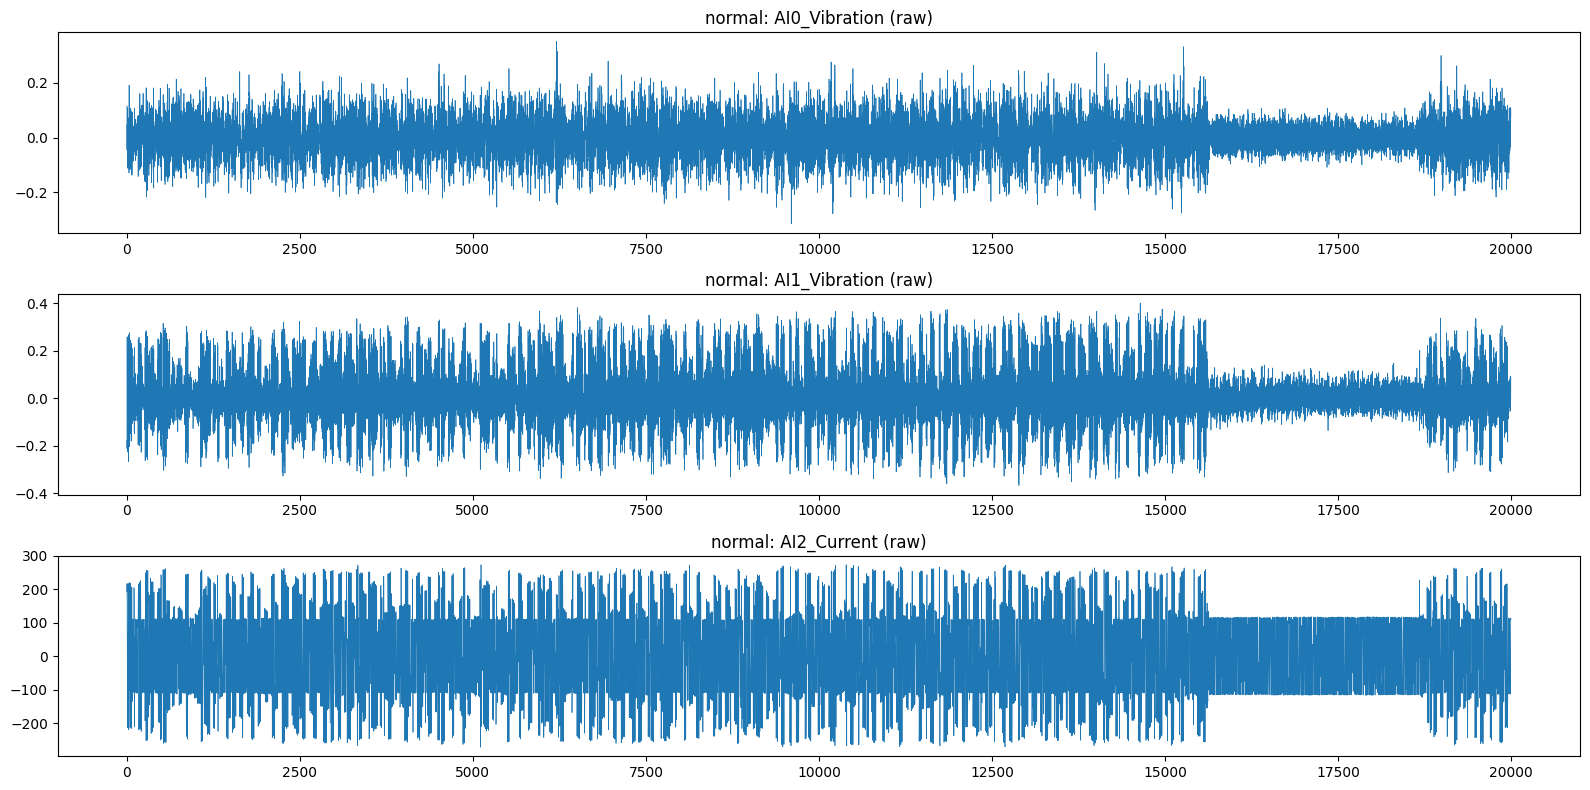

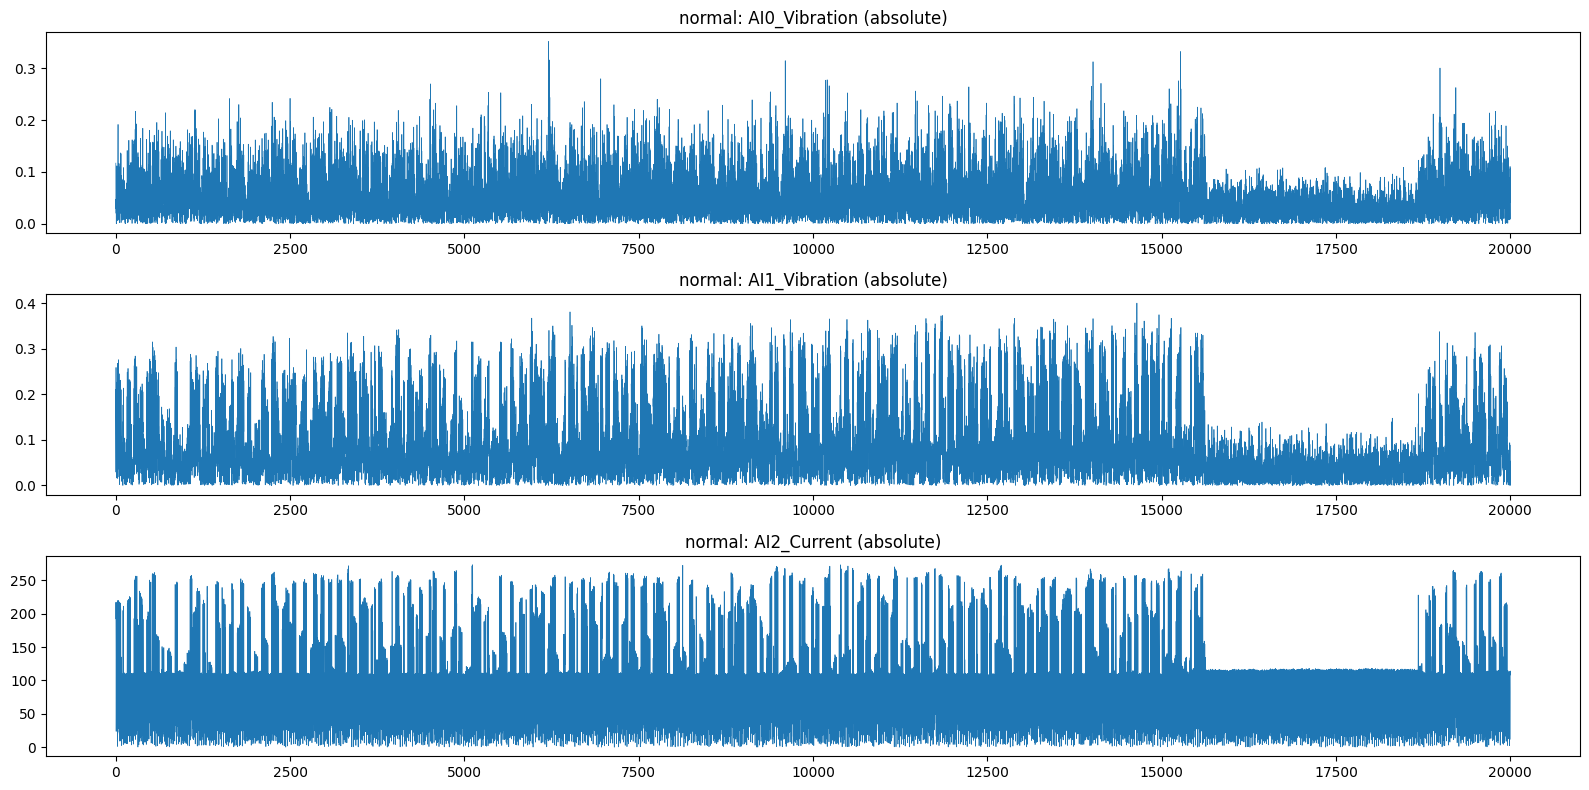

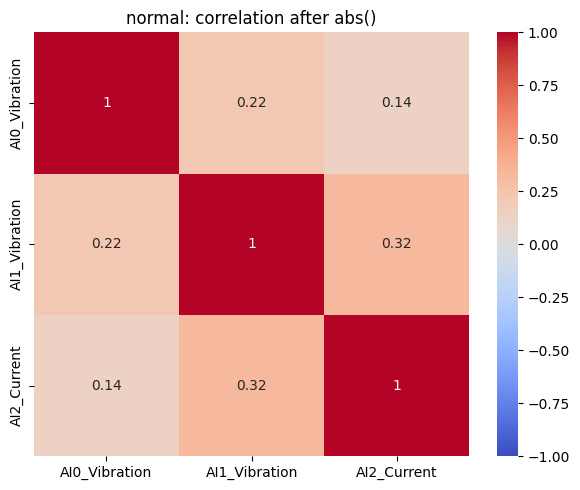

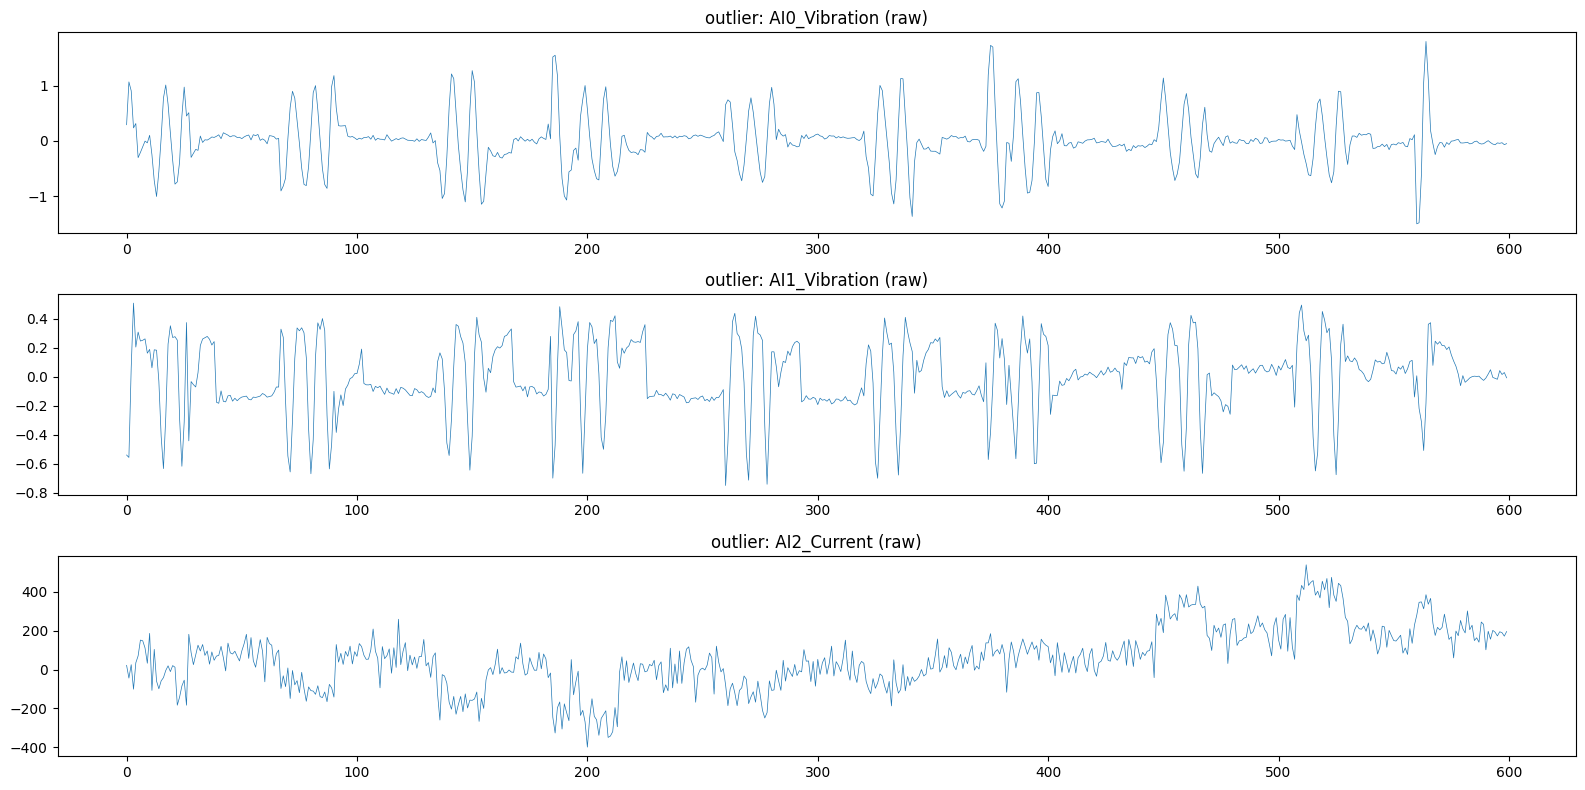

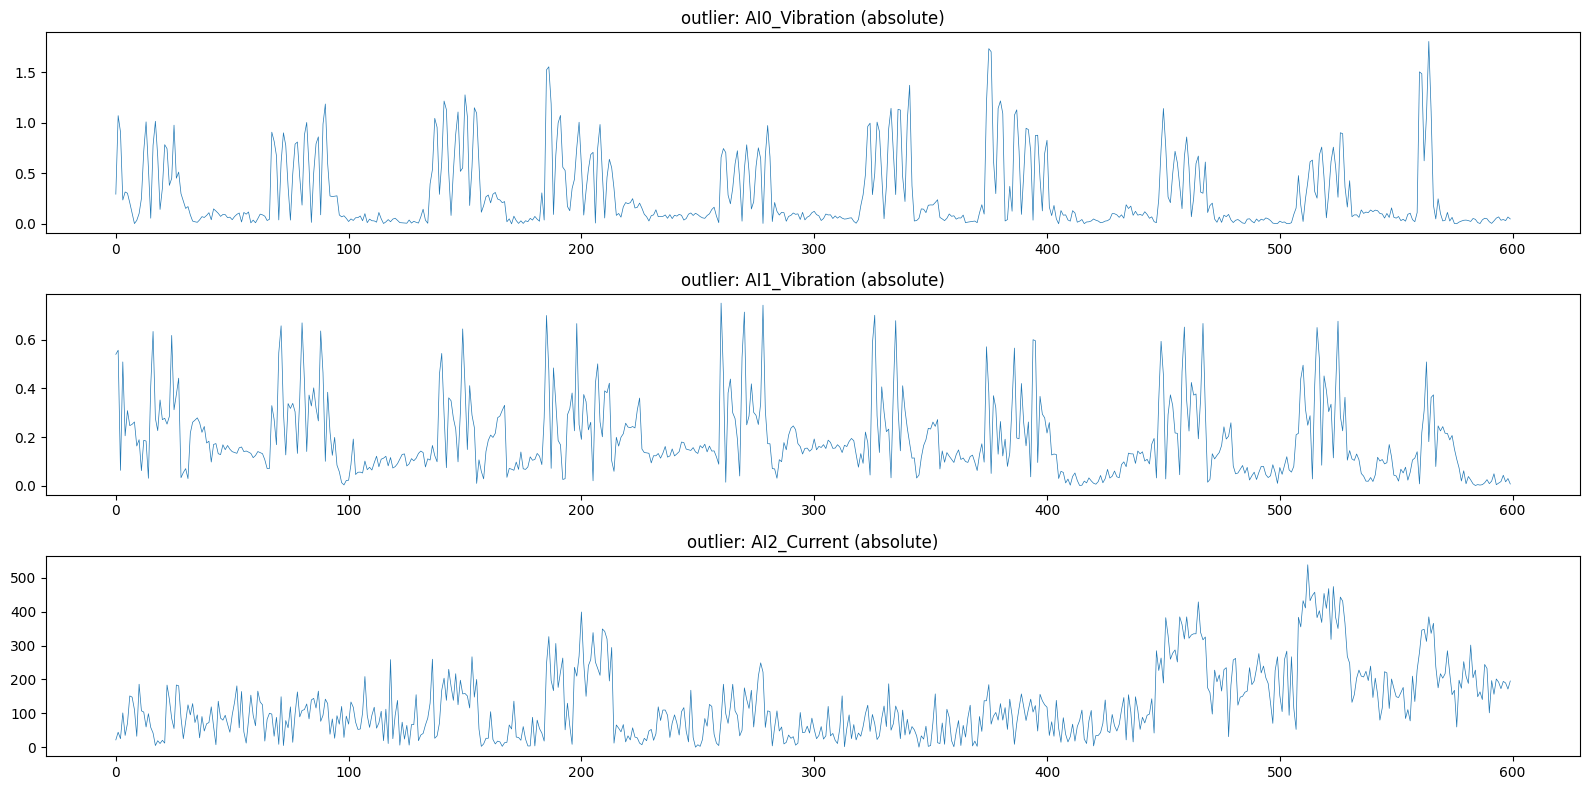

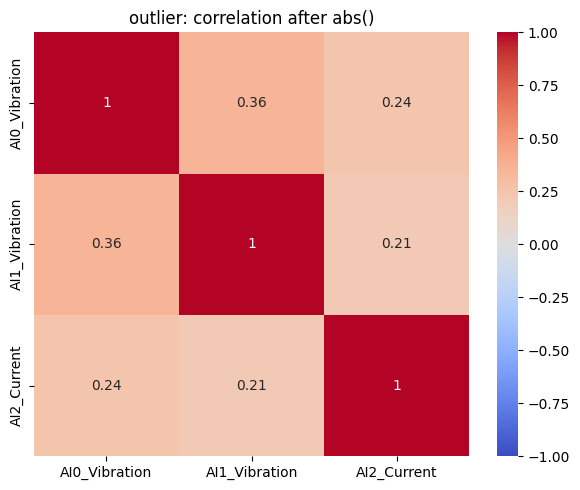

,TimeStamp,AI0_Vibration,AI1_Vibration,AI2_Current,Equipment_state
0,2022-07-12 00:00:00.019,0.116967,-0.176403,192.338730,0
1,2022-07-12 00:00:00.119,0.030080,-0.210895,217.004330,0
2,2022-07-12 00:00:00.219,-0.045794,-0.029424,197.510620,0
3,2022-07-12 00:00:00.319,0.047519,0.258642,156.607170,0
4,2022-07-12 00:00:00.419,0.020351,0.173777,93.236934,0


,TimeStamp,AI0_Vibration,AI1_Vibration,AI2_Current,Equipment_state
0,2022-07-17 10:51:07.943,0.293727,-0.540554,21.457675,1
1,2022-07-17 10:51:08.043,1.070320,-0.557382,-44.107442,1
2,2022-07-17 10:51:08.143,0.908692,0.063108,25.033954,1
3,2022-07-17 10:51:08.243,0.235921,0.509321,-101.327910,1
4,2022-07-17 10:51:16.724,0.315538,0.205315,34.570698,1


,count,mean,std,min,25%,50%,75%,max
AI0_Vibration,20000.0,-0.000094,0.070634,-0.314570,-0.044168,-0.000171,0.044011,0.351699
AI1_Vibration,20000.0,-0.000093,0.118888,-0.366498,-0.069247,-0.009317,0.060176,0.399782
AI2_Current,20000.0,1.446209,122.664494,-271.568330,-101.311693,1.849830,103.844418,273.235000
Equipment_state,20000.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,count,mean,std,min,25%,50%,75%,max
AI0_Vibration,600.0,0.007578,0.447928,-1.502735,-0.116400,0.015771,0.092859,1.803204
AI1_Vibration,600.0,-0.008137,0.241226,-0.751253,-0.136426,0.002161,0.171432,0.509321
AI2_Current,600.0,57.329741,153.172619,-399.351170,-33.378605,53.644187,146.627440,538.826050
Equipment_state,600.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


,normal,outlier
rows,20000,600
missing_by_column,"{'TimeStamp': 0, 'AI0_Vibration': 0, 'AI1_Vibr...","{'TimeStamp': 0, 'AI0_Vibration': 0, 'AI1_Vibr..."
completeness_by_column,"{'TimeStamp': 100.0, 'AI0_Vibration': 100.0, '...","{'TimeStamp': 100.0, 'AI0_Vibration': 100.0, '..."
completeness,100.0,100.0
uniqueness,99.99,100.0
validity,100.0,100.0
consistency_guide_formula,100.0,100.0
actual_numeric_dtypes_valid,True,True
accuracy,None,None
integrity,66.666667,100.0


In [54]:
%%guide
def load_data(data_dir):
    normal = pd.read_csv(Path(data_dir) / "press_data_normal.csv", index_col=0)
    outlier = pd.read_csv(Path(data_dir) / "outlier_data.csv", index_col=0)
    for name, df, rows, state in [("normal", normal, 20000, 0), ("outlier", outlier, 600, 1)]:
        if list(df.columns) != ["TimeStamp"] + FEATURES + ["Equipment_state"]:
            raise ValueError(f"Unexpected {name} columns: {list(df.columns)}")
        if len(df) != rows or not df.Equipment_state.eq(state).all():
            raise ValueError(f"Unexpected {name} row count or labels")
        if df.isna().any().any() or not np.isfinite(df[FEATURES].to_numpy()).all():
            raise ValueError(f"Missing/non-finite data in {name}; do not silently change guidebook data")
    return normal, outlier
def quality_report(df, day):
    """Appendix p.56-63 formulas, plus an actual type check and duplicate diagnostics."""
    completeness = (1 - df.isna().mean()) * 100
    counts = df.value_counts()
    uniqueness = round((len(counts) - (counts > 1).sum()) / len(counts) * 100, 2)
    timestamps = pd.to_datetime(df.TimeStamp, errors="coerce")
    validity = timestamps.between(pd.Timestamp(day), pd.Timestamp(day) + pd.Timedelta(days=1), inclusive="left").mean() * 100
    consistency = 100.0  # literal appendix code: len(data) / len(data) * 100
    integrity = (1 - sum(x != 100 for x in [uniqueness, validity, consistency]) / 3) * 100
    dtypes_ok = all(str(df[c].dtype) == "float64" for c in FEATURES) and str(df.Equipment_state.dtype) == "int64"
    return {
        "rows": len(df), "missing_by_column": df.isna().sum().to_dict(),
        "completeness_by_column": completeness.to_dict(), "completeness": completeness.mean(),
        "uniqueness": uniqueness, "validity": validity, "consistency_guide_formula": consistency,
        "actual_numeric_dtypes_valid": dtypes_ok, "accuracy": None, "integrity": integrity,
        "weighted_quality": completeness.mean() * .6 + (uniqueness + validity + consistency + integrity) * .1,
        "duplicate_rows_after_first": int(df.duplicated().sum()),
        "duplicate_timestamps_after_first": int(timestamps.duplicated().sum()),
        "timestamp_monotonic": bool(timestamps.is_monotonic_increasing),
        "timestamp_step_seconds": timestamps.diff().dt.total_seconds().value_counts().head(10).to_dict(),
        "note": "Guide consistency formula always returns 100%; accuracy is not assessed. No rows removed.",
    }
def save_plot(path):
    plt.tight_layout()
    plt.savefig(path, dpi=140)
    plt.show()
    plt.close()
def explore(normal, outlier, output):
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    save_json(output / "data_quality.json", {
        "normal": quality_report(normal, "2022-07-12"),
        "outlier": quality_report(outlier, "2022-07-17"),
    })
    for name, df in [("normal", normal), ("outlier", outlier)]:
        df.head().to_csv(output / f"{name}_head.csv", encoding="utf-8-sig")
        df.describe().T.to_csv(output / f"{name}_describe.csv", encoding="utf-8-sig")
        for mode, data in [("raw", df[FEATURES]), ("absolute", df[FEATURES].abs())]:
            fig, axes = plt.subplots(3, 1, figsize=(16, 8))
            for col, ax in zip(FEATURES, axes):
                ax.plot(data[col], linewidth=.5)
                ax.set_title(f"{name}: {col} ({mode})")
            save_plot(output / f"{name}_{mode}.png")
        corr = df[FEATURES].abs().corr()
        corr.to_csv(output / f"{name}_correlation.csv")
        plt.figure(figsize=(6, 5))
        sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="coolwarm")
        plt.title(f"{name}: correlation after abs()")
        save_plot(output / f"{name}_correlation.png")

normal,outlier=load_data(DATA_DIR)
explore(normal,outlier,output/"eda")
display(normal.head()); display(outlier.head())
display(normal.describe().T); display(outlier.describe().T)
quality=json.loads((output/"eda/data_quality.json").read_text())
display(pd.DataFrame(quality))


## 7. 전처리·윈도우·분할

절댓값과 MinMaxScaler, 길이 20·offset 100, 정상 15,000행 학습 구간을 그대로 유지합니다. Train 14,880, Valid 1,180, Test 4,180 윈도우입니다. 원문처럼 윈도우를 만든 뒤 Valid/Test를 나누므로 입력 경계에서 19행이 겹칩니다.

In [55]:
%%guide
def make_windows(x, y, sequence=20, offset=100):
    # p.32 code 21: restore missing '-' before 100 in the first two loops.
    xx, yy = [], []
    for index in range(len(x) - sequence - offset):
        xx.append(x[index:index + sequence])
        yy.append(y[index + sequence + offset])
    return np.array(xx), np.array(yy)
def prepare(normal, outlier, cfg):
    # p.27 code 14, p.30-34 codes 19-24. Do not clip transformed test anomalies.
    normal_data, outlier_data = normal.copy(), outlier.copy()
    normal_data[FEATURES] = normal_data[FEATURES].applymap(lambda x: abs(x))
    outlier_data[FEATURES] = outlier_data[FEATURES].applymap(lambda x: abs(x))
    scaler = MinMaxScaler()
    train = scaler.fit_transform(normal_data[FEATURES][:cfg.train_rows])
    test_normal = scaler.transform(normal_data[FEATURES][cfg.train_rows:])
    test_anomaly = scaler.transform(outlier_data[FEATURES])
    x_train, y_train = make_windows(train, normal_data.Equipment_state.to_numpy()[:cfg.train_rows], cfg.sequence, cfg.label_offset)
    xn, yn = make_windows(test_normal, normal_data.Equipment_state.to_numpy()[cfg.train_rows:], cfg.sequence, cfg.label_offset)
    xa, ya = make_windows(test_anomaly, outlier_data.Equipment_state.to_numpy(), cfg.sequence, cfg.label_offset)
    x_valid = np.vstack((xn[:cfg.valid_normal], xa[:cfg.valid_anomaly]))
    y_valid = np.hstack((yn[:cfg.valid_normal], ya[:cfg.valid_anomaly]))
    x_test = np.vstack((xn[cfg.valid_normal:], xa[cfg.valid_anomaly:]))
    y_test = np.hstack((yn[cfg.valid_normal:], ya[cfg.valid_anomaly:]))
    result = dict(X_train=x_train, Y_train=y_train, X_valid=x_valid, Y_valid=y_valid,
                  X_test=x_test, Y_test=y_test, X_valid_0=x_valid[y_valid == 0], scaler=scaler)
    expected = {"X_train": (14880, 20, 3), "X_valid": (1180, 20, 3), "X_test": (4180, 20, 3), "X_valid_0": (880, 20, 3)}
    if (cfg.sequence, cfg.label_offset, cfg.train_rows, cfg.valid_normal, cfg.valid_anomaly) == (20, 100, 15000, 880, 300):
        for key, shape in expected.items():
            assert result[key].shape == shape, (key, result[key].shape)
    return result
def split_manifest(normal, outlier, cfg):
    frames = []
    # Original row positions and label times make the guidebook's overlap auditable.
    for source, df, start, n, nv in [
        ("normal_train", normal, 0, cfg.train_rows - cfg.sequence - cfg.label_offset, 0),
        ("normal", normal, cfg.train_rows, len(normal) - cfg.train_rows - cfg.sequence - cfg.label_offset, cfg.valid_normal),
        ("anomaly", outlier, 0, len(outlier) - cfg.sequence - cfg.label_offset, cfg.valid_anomaly),
    ]:
        for i in range(n):
            first, last, label = start + i, start + i + cfg.sequence - 1, start + i + cfg.sequence + cfg.label_offset
            frames.append({"split": "train" if source == "normal_train" else ("valid" if i < nv else "test"),
                           "source": "normal" if source == "normal_train" else source,
                           "input_start_row": first, "input_end_row": last, "label_row": label,
                           "input_end_time": df.iloc[last].TimeStamp, "label_time": df.iloc[label].TimeStamp,
                           "label": int(df.iloc[label].Equipment_state)})
    return pd.DataFrame(frames)

data=prepare(normal,outlier,cfg)
manifest=split_manifest(normal,outlier,cfg)
manifest.to_csv(output/"split_manifest.csv",index=False,encoding="utf-8-sig")
joblib.dump(data["scaler"],output/"scaler.joblib")
shapes={k:list(v.shape) for k,v in data.items() if isinstance(v,np.ndarray)}
save_json(output/"split_shapes.json",shapes)
display(pd.DataFrame(shapes.items(),columns=["데이터","shape"]))
display(manifest.groupby(["split","label"]).size().unstack(fill_value=0))


,데이터,shape
0,X_train,"[14880, 20, 3]"
1,Y_train,[14880]
2,X_valid,"[1180, 20, 3]"
3,Y_valid,[1180]
4,X_test,"[4180, 20, 3]"
5,Y_test,[4180]
6,X_valid_0,"[880, 20, 3]"


label,0,1
split,,
test,4000,180
train,14880,0
valid,880,300


## 8. 모델과 학습 정의

LSTM 64→32→RepeatVector(20)→LSTM 32→64→Dense(3). MSE, Adam 0.001, batch=128, 최대 800 epoch, ReduceLR와 EarlyStopping을 적용합니다. 정상 Valid만 학습 모니터링에 사용합니다. 윈도우 내부 순서는 유지하고 윈도우 간 순서만 섞습니다.

In [56]:
%%guide
# TensorFlow 가이드의 LSTM AE 구조를 PyTorch로 옮깁니다.
class LSTMAutoencoder(nn.Module):
    def __init__(self, sequence):
        super().__init__()
        self.sequence=sequence
        self.encoder1 = nn.LSTM(3,64,batch_first=True)
        self.encoder2 = nn.LSTM(64,32,batch_first=True)
        self.decoder1 = nn.LSTM(32,32,batch_first=True)
        self.decoder2 = nn.LSTM(32,64,batch_first=True)
        self.output = nn.Linear(64,3)
        # Keras 기본 초기화 방식: 입력 Glorot, 순환 orthogonal, forget gate bias=1.
        # PyTorch의 추가 recurrent bias는 0에 고정해 Keras와 같은 학습 파라미터 수를 유지합니다.
        for layer in (self.encoder1,self.encoder2,self.decoder1,self.decoder2):
            nn.init.xavier_uniform_(layer.weight_ih_l0)
            nn.init.orthogonal_(layer.weight_hh_l0)
            nn.init.zeros_(layer.bias_ih_l0)
            with torch.no_grad(): layer.bias_ih_l0[layer.hidden_size:2*layer.hidden_size].fill_(1)
            nn.init.zeros_(layer.bias_hh_l0)
            layer.bias_hh_l0.requires_grad_(False)
        nn.init.xavier_uniform_(self.output.weight)
        nn.init.zeros_(self.output.bias)
    def forward(self,x):
        x,_ = self.encoder1(x)
        _,(hidden,_) = self.encoder2(x)
        x = hidden[-1].unsqueeze(1).repeat(1,self.sequence,1)
        x,_ = self.decoder1(x)
        x,_ = self.decoder2(x)
        return self.output(x)

    @torch.inference_mode()
    def predict(self,x,verbose=0):
        self.eval()
        return np.concatenate([self(torch.tensor(x[i:i+32],dtype=torch.float32,device=device)).cpu().numpy()
                               for i in range(0,len(x),32)])
# PyTorch 기본 Adam과 Keras Adam은 epsilon의 위치가 달라 가이드 계산식을 명시합니다.
class KerasAdam(torch.optim.Optimizer):
    def __init__(self,params,lr=.001):
        super().__init__(params,dict(lr=lr,beta1=.9,beta2=.999,eps=1e-7,step=0))
    @torch.no_grad()
    def step(self,closure=None):
        for group in self.param_groups:
            group["step"] += 1
            anchor = group["params"][0]
            b1,b2 = [torch.tensor(group[k],dtype=anchor.dtype,device=anchor.device) for k in ("beta1","beta2")]
            alpha = torch.tensor(group["lr"],dtype=anchor.dtype,device=anchor.device)*(1-b2.pow(group["step"])).sqrt()/(1-b1.pow(group["step"]))
            for p in group["params"]:
                if p.grad is None: continue
                if not self.state[p]:
                    self.state[p]["m"] = torch.zeros_like(p)
                    self.state[p]["v"] = torch.zeros_like(p)
                m,v = self.state[p]["m"],self.state[p]["v"]
                m.add_((p.grad-m)*(1-b1))
                v.add_((p.grad.square()-v)*(1-b2))
                p.add_(-alpha*m/(v.sqrt()+group["eps"]))
def train_model(data, cfg, output):
    model = LSTMAutoencoder(cfg.sequence).to(device)
    print(model)
    print("학습 파라미터 수:", sum(p.numel() for p in model.parameters() if p.requires_grad))
    (output/"model_summary.txt").write_text(str(model),encoding="utf-8")
    optimizer = KerasAdam([p for p in model.parameters() if p.requires_grad],
                          lr=float(np.float32(cfg.learning_rate)))
    generator = torch.Generator().manual_seed(cfg.seed)
    train_loader = DataLoader(TensorDataset(torch.tensor(data["X_train"],dtype=torch.float32)),
        batch_size=cfg.batch_size, shuffle=True, generator=generator, num_workers=0)
    valid_loader = DataLoader(TensorDataset(torch.tensor(data["X_valid_0"],dtype=torch.float32)),
        batch_size=cfg.batch_size, shuffle=False, num_workers=0)
    loss_fn = nn.MSELoss()
    best_loss = lr_best = float("inf")
    best_epoch = early_wait = lr_wait = 0
    early_stopped = False
    rows=[]
    started=time.perf_counter()
    for epoch in range(cfg.epochs):
        epoch_started=time.perf_counter()
        current_lr=optimizer.param_groups[0]["lr"]
        model.train()
        total=0.0
        for (x,) in train_loader:
            x=x.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss=loss_fn(model(x),x)
            loss.backward()
            optimizer.step()
            total+=float(loss.detach())*len(x)
        train_loss=total/len(data["X_train"])
        model.eval()
        with torch.inference_mode():
            total=0.0
            for (x,) in valid_loader:
                x=x.to(device)
                total+=float(loss_fn(model(x),x))*len(x)
        valid_loss=total/len(data["X_valid_0"])
        # Keras ReduceLROnPlateau의 기본 min_delta=1e-4(절대 차이)를 사용합니다.
        if valid_loss < lr_best-1e-4:
            lr_best,lr_wait=valid_loss,0
        else:
            lr_wait+=1
            if lr_wait>=cfg.lr_patience:
                for group in optimizer.param_groups:
                    group["lr"]=float(np.float32(group["lr"]*cfg.lr_factor))
                lr_wait=0
        early_wait+=1
        if valid_loss+cfg.es_min_delta < best_loss:
            best_loss,best_epoch,early_wait=valid_loss,epoch,0
            best_weights={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
        if early_wait>=cfg.es_patience and epoch>0:
            early_stopped=True
            model.load_state_dict(best_weights)
        rows.append(dict(epoch=epoch,loss=train_loss,val_loss=valid_loss,lr=current_lr,
                         epoch_seconds=time.perf_counter()-epoch_started))
        if epoch==0 or (epoch+1)%10==0:
            print(f"Epoch {epoch+1}: loss={train_loss:.8f}, val_loss={valid_loss:.8f}",flush=True)
        if early_stopped: break
    history=pd.DataFrame(rows)
    history.to_csv(output/"history.csv",index=False)
    training=dict(seconds=time.perf_counter()-started,epochs_run=len(history),epoch_limit=cfg.epochs,
        early_stopped=early_stopped,best_val_loss=float(history.val_loss.min()),
        minimum_val_loss_epoch=int(history.val_loss.argmin()+1),early_stopping_best_val_loss=best_loss,
        final_weights="EarlyStopping restored weights" if early_stopped else "last epoch (TF 2.7 guide behavior)")
    torch.save({"model_state_dict":model.state_dict(),"config":asdict(cfg)},output/"model.pt")
    save_json(output/"training.json",training)
    plt.figure(figsize=(10,5))
    plt.plot(history.loss,label="train loss")
    plt.plot(history.val_loss,label="valid loss")
    plt.xlabel("Epoch (zero based)"); plt.ylabel("MSE loss"); plt.legend()
    save_plot(output/"loss.png")
    return model,training


## 9. 학습 실행

조기 종료가 발생하면 최적 가중치를 복원합니다. 최대 epoch 도달 시에는 TF 2.7의 동작대로 마지막 가중치를 평가합니다.

LSTMAutoencoder(
  (encoder1): LSTM(3, 64, batch_first=True)
  (encoder2): LSTM(64, 32, batch_first=True)
  (decoder1): LSTM(32, 32, batch_first=True)
  (decoder2): LSTM(32, 64, batch_first=True)
  (output): Linear(in_features=64, out_features=3, bias=True)
)
학습 파라미터 수: 63171
Epoch 1: loss=0.04110418, val_loss=0.02719680
Epoch 10: loss=0.02037639, val_loss=0.01724800
Epoch 20: loss=0.01469495, val_loss=0.01333733
Epoch 30: loss=0.01394232, val_loss=0.01233297
Epoch 40: loss=0.01338239, val_loss=0.01178544
Epoch 50: loss=0.01294052, val_loss=0.01153793
Epoch 60: loss=0.01258543, val_loss=0.01101468
Epoch 70: loss=0.01215232, val_loss=0.01069462
Epoch 80: loss=0.01143006, val_loss=0.00991999
Epoch 90: loss=0.01076514, val_loss=0.00946014
Epoch 100: loss=0.00956615, val_loss=0.00866707
Epoch 110: loss=0.00765725, val_loss=0.00717873
Epoch 120: loss=0.00697129, val_loss=0.00654239
Epoch 130: loss=0.00638070, val_loss=0.00598351
Epoch 140: loss=0.00592205, val_loss=0.00568688
Epoch 150: los

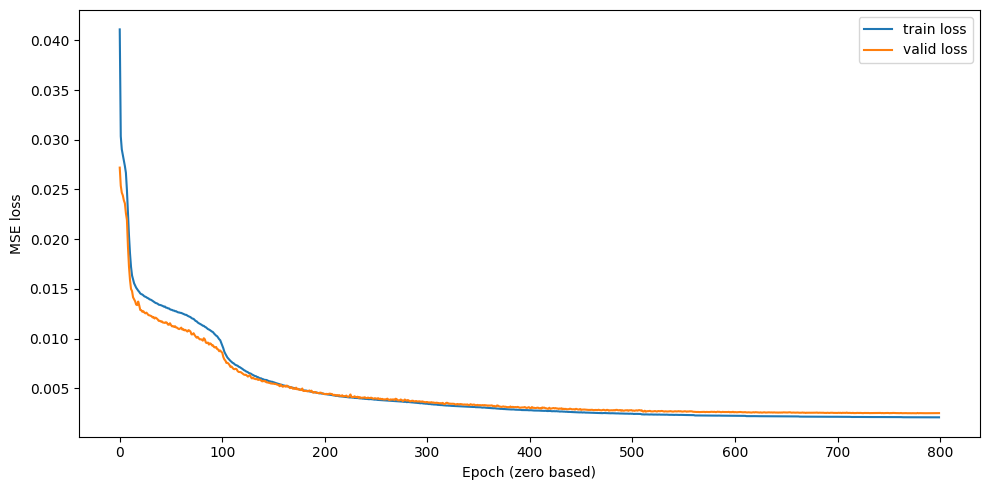

,학습 결과,값
0,seconds,709.600053
1,epochs_run,800
2,epoch_limit,800
3,early_stopped,False
4,best_val_loss,0.002477
5,minimum_val_loss_epoch,778
6,early_stopping_best_val_loss,0.002481
7,final_weights,last epoch (TF 2.7 guide behavior)


In [57]:
%%guide
model,training=train_model(data,cfg,output)
display(pd.DataFrame(training.items(),columns=["학습 결과","값"]))


## 10. Valid 임계값 선정과 Test 평가

마지막 시점의 3채널 MSE를 점수로 사용합니다. Valid에서 precision==recall인 첫 임계값을 택하고, score>threshold일 때 이상으로 판정합니다. 가이드 PR 그림의 한 칸 이동 표현은 원래 코드대로 유지하며, 올바른 대응 수치는 threshold_curve.csv에 저장합니다.

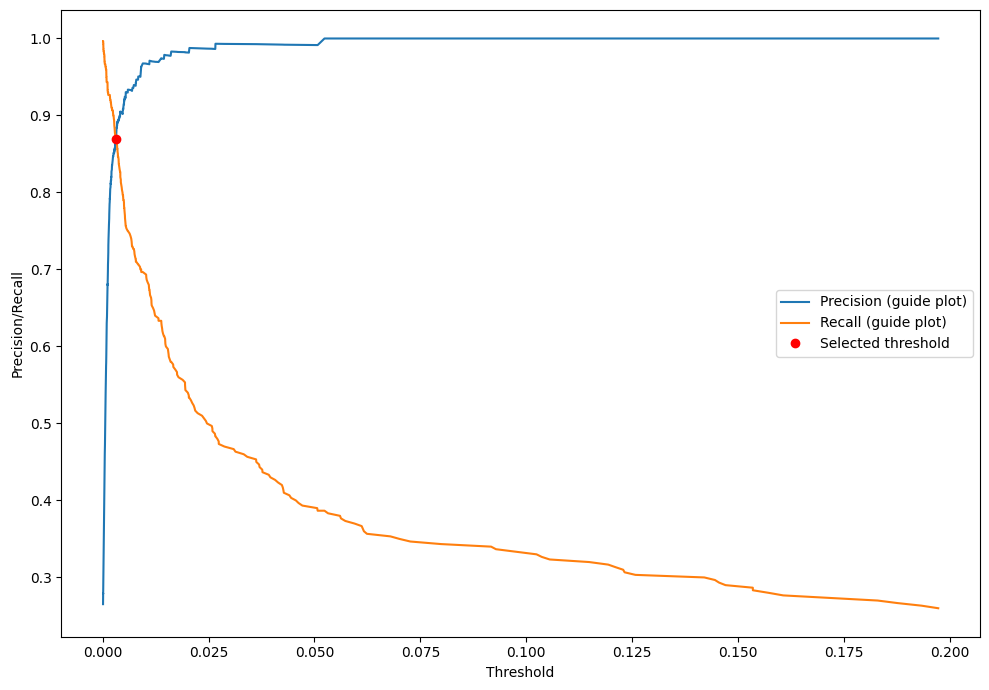

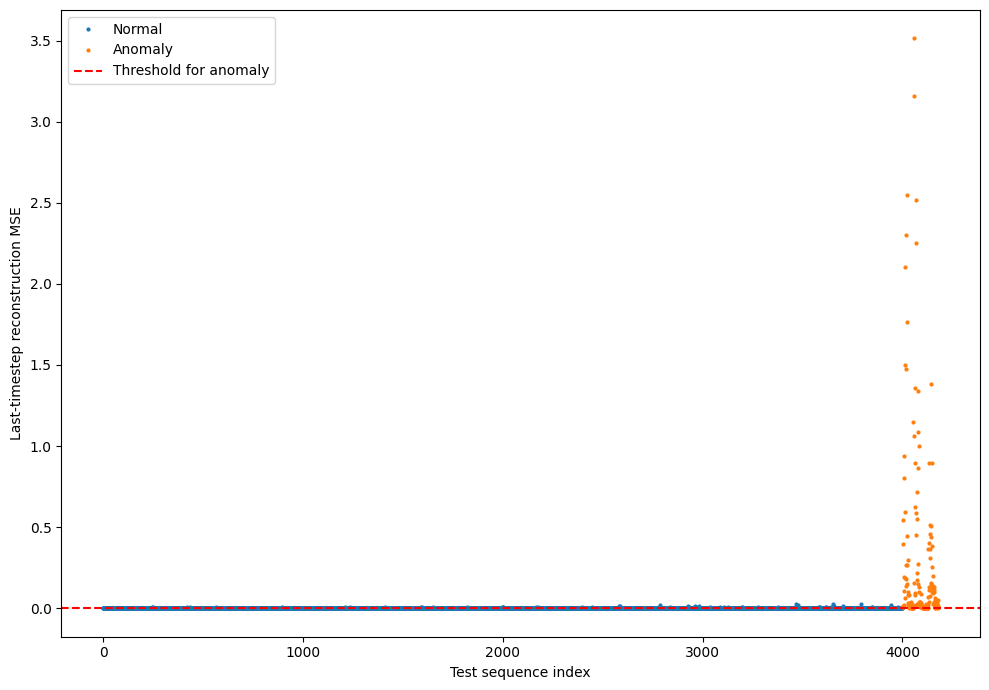

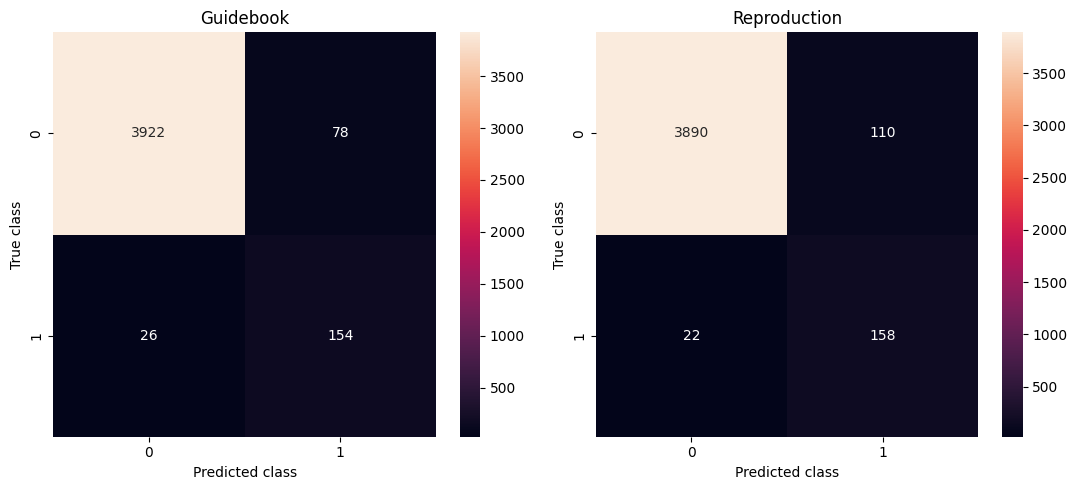

,Guidebook,PyTorch
accuracy,0.975120,0.968421
precision,0.663793,0.589552
recall,0.855556,0.877778
f1,0.747573,0.705357


,지표,값
0,임계값,0.003053
1,정상 오경보율,0.027500
2,이상 미탐률,0.122222


In [58]:
%%guide
def flatten(x):
    # Printed p.36 code 28: ONLY the last time step, not the entire window.
    flattened = np.empty((x.shape[0], x.shape[2]))
    for i in range(x.shape[0]):
        flattened[i] = x[i, x.shape[1] - 1, :]
    return flattened
def select_threshold(y, scores):
    precision, recall, thresholds = metrics.precision_recall_curve(list(y), scores)
    matches = [i for i, (p, r) in enumerate(zip(precision[:-1], recall[:-1])) if p == r]
    if not matches:
        raise ValueError("Guidebook's exact precision == recall rule found no threshold; no silent replacement.")
    i = matches[0]
    return float(thresholds[i]), i, precision, recall, thresholds
def evaluate(model, data, output, manifest):
    valid_pred = model.predict(data["X_valid"], verbose=0)
    valid_scores = np.mean(np.power(flatten(data["X_valid"]) - flatten(valid_pred), 2), axis=1)
    threshold, index, precision, recall, thresholds = select_threshold(data["Y_valid"], valid_scores)
    pd.DataFrame({"threshold": thresholds, "precision": precision[:-1], "recall": recall[:-1]}).to_csv(output / "threshold_curve.csv", index=False)
    plt.figure(figsize=(10, 7))
    mask = thresholds <= .2
    # Preserve the original code 29 plotting shift; report notes it explicitly.
    plt.plot(thresholds[mask], precision[1:][mask], label="Precision (guide plot)")
    plt.plot(thresholds[mask], recall[1:][mask], label="Recall (guide plot)")
    plt.plot(threshold, precision[index], "o", color="r", label="Selected threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Precision/Recall")
    plt.legend()
    save_plot(output / "threshold_guide.png")
    scores = np.mean(np.power(flatten(data["X_test"]) - flatten(model.predict(data["X_test"], verbose=0)), 2), axis=1)
    pred_y = np.array([1 if e > threshold else 0 for e in scores])
    y = data["Y_test"]
    cm = metrics.confusion_matrix(list(y), pred_y, labels=[0, 1])
    validation_actual = (valid_scores > threshold).astype(int)
    result = {
        "accuracy": metrics.accuracy_score(y, pred_y),
        "precision": metrics.precision_score(y, pred_y, zero_division=0),
        "recall": metrics.recall_score(y, pred_y, zero_division=0),
        "f1": metrics.f1_score(y, pred_y, zero_division=0),
        "roc_auc": metrics.roc_auc_score(y, scores),
        "average_precision": metrics.average_precision_score(y, scores),
        "threshold": threshold, "confusion_matrix": cm,
        "normal_false_positive_rate": cm[0, 1] / cm[0].sum(),
        "anomaly_miss_rate": cm[1, 0] / cm[1].sum(),
        "validation_curve_precision": precision[index], "validation_curve_recall": recall[index],
        "validation_strict_precision": metrics.precision_score(data["Y_valid"], validation_actual),
        "validation_strict_recall": metrics.recall_score(data["Y_valid"], validation_actual),
        "guidebook": GUIDE,
        "difference_percentage_points": {k: (v - GUIDE[k]) * 100 for k, v in {
            "accuracy": metrics.accuracy_score(y, pred_y), "f1": metrics.f1_score(y, pred_y),
            "precision": metrics.precision_score(y, pred_y), "recall": metrics.recall_score(y, pred_y)}.items()},
    }
    save_json(output / "metrics.json", result)
    for split, split_scores, labels in [("valid", valid_scores, data["Y_valid"]), ("test", scores, y)]:
        rows = manifest[manifest.split == split].copy()
        assert np.array_equal(rows.label.to_numpy(), labels)
        rows["reconstruction_mse"] = split_scores
        rows["predicted_label"] = (split_scores > threshold).astype(int)
        rows["threshold"] = threshold
        rows.to_csv(output / f"{split}_predictions.csv", index=False, encoding="utf-8-sig")
    plt.figure(figsize=(10, 7))
    plt.plot(np.where(y == 0)[0], scores[y == 0], "o", markersize=2, label="Normal")
    plt.plot(np.where(y == 1)[0], scores[y == 1], "o", markersize=2, label="Anomaly")
    plt.axhline(threshold, color="r", linestyle="--", label="Threshold for anomaly")
    plt.ylabel("Last-timestep reconstruction MSE")
    plt.xlabel("Test sequence index")
    plt.legend()
    save_plot(output / "reconstruction_error.png")
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, matrix, title in [(axes[0], GUIDE_CM, "Guidebook"), (axes[1], cm, "Reproduction")]:
        sns.heatmap(matrix, annot=True, fmt="d", xticklabels=[0, 1], yticklabels=[0, 1], ax=ax)
        ax.set(title=title, xlabel="Predicted class", ylabel="True class")
    save_plot(output / "confusion_matrix.png")
    return result

result=evaluate(model,data,output,manifest)
comparison=pd.DataFrame({"Guidebook":{k:GUIDE[k] for k in ["accuracy","precision","recall","f1"]},
                         FRAMEWORK:{k:result[k] for k in ["accuracy","precision","recall","f1"]}})
display(comparison)
display(pd.DataFrame({"지표":["임계값","정상 오경보율","이상 미탐률"],
    "값":[result["threshold"],result["normal_false_positive_rate"],result["anomaly_miss_rate"]]}))
comparison.to_csv(output/"guide_comparison.csv")


## 11. 오경보·미탐 확인

원본 행과 시각으로 오류 위치를 확인합니다. 중첩 윈도우 개수는 독립적인 고장 사건 수와 다릅니다. 원본 두 파일은 각각 단일 라벨이므로 이 평가만으로 고장 전환 이전의 조기경보 시간을 입증하지는 않습니다.

In [59]:
%%guide
for split in ["valid","test"]:
    predictions=pd.read_csv(output/f"{split}_predictions.csv")
    fp=(predictions.label==0)&(predictions.predicted_label==1)
    fn=(predictions.label==1)&(predictions.predicted_label==0)
    predictions["outcome"]=np.select([fp,fn],["FP","FN"],default="correct")
    errors=predictions[fp|fn]
    errors.to_csv(output/f"{split}_error_cases.csv",index=False,encoding="utf-8-sig")
    print(split, "FP:",int(fp.sum()),"FN:",int(fn.sum()))
    display(errors.head(20))


valid FP: 38 FN: 39


,split,source,input_start_row,input_end_row,label_row,input_end_time,label_time,label,reconstruction_mse,predicted_label,threshold,outcome
10,valid,normal,15010,15029,15130,2022-07-12 00:57:20.685,2022-07-12 00:57:40.947,0,0.008952,1,0.003053,FP
11,valid,normal,15011,15030,15131,2022-07-12 00:57:20.785,2022-07-12 00:57:41.047,0,0.004127,1,0.003053,FP
21,valid,normal,15021,15040,15141,2022-07-12 00:57:30.180,2022-07-12 00:57:44.892,0,0.026606,1,0.003053,FP
22,valid,normal,15022,15041,15142,2022-07-12 00:57:30.280,2022-07-12 00:57:44.992,0,0.006998,1,0.003053,FP
24,valid,normal,15024,15043,15144,2022-07-12 00:57:30.480,2022-07-12 00:57:45.192,0,0.003201,1,0.003053,FP
25,valid,normal,15025,15044,15145,2022-07-12 00:57:30.580,2022-07-12 00:57:45.292,0,0.003389,1,0.003053,FP
26,valid,normal,15026,15045,15146,2022-07-12 00:57:30.680,2022-07-12 00:57:45.392,0,0.003347,1,0.003053,FP
114,valid,normal,15114,15133,15234,2022-07-12 00:57:41.247,2022-07-12 00:58:18.087,0,0.005084,1,0.003053,FP
121,valid,normal,15121,15140,15241,2022-07-12 00:57:44.792,2022-07-12 00:58:18.787,0,0.005395,1,0.003053,FP
161,valid,normal,15161,15180,15281,2022-07-12 00:57:52.887,2022-07-12 00:58:24.793,0,0.003627,1,0.003053,FP


test FP: 110 FN: 22


,split,source,input_start_row,input_end_row,label_row,input_end_time,label_time,label,reconstruction_mse,predicted_label,threshold,outcome
111,test,normal,15991,16010,16111,2022-07-12 01:01:04.524,2022-07-12 01:01:21.296,0,0.004238,1,0.003053,FP
112,test,normal,15992,16011,16112,2022-07-12 01:01:04.624,2022-07-12 01:01:21.396,0,0.003152,1,0.003053,FP
113,test,normal,15993,16012,16113,2022-07-12 01:01:04.724,2022-07-12 01:01:21.496,0,0.003789,1,0.003053,FP
247,test,normal,16127,16146,16247,2022-07-12 01:01:28.271,2022-07-12 01:01:45.706,0,0.008363,1,0.003053,FP
248,test,normal,16128,16147,16248,2022-07-12 01:01:28.371,2022-07-12 01:01:45.806,0,0.005848,1,0.003053,FP
250,test,normal,16130,16149,16250,2022-07-12 01:01:28.571,2022-07-12 01:01:46.006,0,0.003594,1,0.003053,FP
291,test,normal,16171,16190,16291,2022-07-12 01:01:36.260,2022-07-12 01:01:53.760,0,0.004275,1,0.003053,FP
292,test,normal,16172,16191,16292,2022-07-12 01:01:36.360,2022-07-12 01:01:53.860,0,0.003916,1,0.003053,FP
342,test,normal,16222,16241,16342,2022-07-12 01:01:45.106,2022-07-12 01:02:09.125,0,0.003157,1,0.003053,FP
419,test,normal,16299,16318,16419,2022-07-12 01:02:00.918,2022-07-12 01:02:40.798,0,0.004592,1,0.003053,FP


## 12. 결과 다운로드

In [ ]:
# 실행 결과를 이 Colab에서 내려받습니다.
import zipfile
result_dir = Path(OUTPUT_ROOT)/RUN_ID
if DOWNLOAD_RESULTS:
    archive_path = result_dir.parent/(RUN_ID+"_results.zip")
    with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
        for path in sorted(result_dir.iterdir()):
            if path.is_file():
                archive.write(path, path.name)
    files.download(str(archive_path))
else:
    print("분석·학습·평가 결과는 위 셀과 Colab 파일 목록에서 확인할 수 있습니다.")
    print("ZIP 다운로드는 설정의 DOWNLOAD_RESULTS=True로 바꾼 후 이 셀을 실행하세요.")


분석·학습·평가 결과는 위 셀과 Colab 파일 목록에서 확인할 수 있습니다.
ZIP 다운로드는 설정의 DOWNLOAD_RESULTS=True로 바꾼 후 이 셀을 실행하세요.
